# 06. 상세 지도·입지 후보 비교

입력: 01번이 저장한 음식점·주택·단속 좌표와 출처 기록. 자동 우선 행정동은 05번의 요약 JSON에서 읽습니다.

송천1동만 분석할 때는 ANALYZE_AUTO_SELECTED를 False로 설정하면 05번 요약 없이 실행할 수 있습니다.

출력: 상세 지도, 후보지 표, 후보 점수 및 요약. 주황색 후보는 새 규칙이며 보라색은 발표에 나온 붓내3길·5길 주소 건물의 범위입니다.

각 노트북은 별도 커널에서 실행할 수 있습니다. 공유 변수는 사용하지 않고 파일로 입력을 읽습니다. ZIP에는 기존 실행 결과도 들어 있습니다.

In [1]:
from pathlib import Path
import sys
# Supports Jupyter launched from the repository root or notebooks/.
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src' / 'paths.py').exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('저장소 폴더 또는 notebooks 폴더에서 노트북을 실행하세요.')
sys.path.insert(0, str(PROJECT_ROOT))
from src.paths import ROOT, data_path, result_path

# 필요 시 주석 해제
# %pip install -r requirements.txt
from IPython.display import Image, HTML, display


In [2]:
"""PDF 기반 재구현. 원본 코드 복원이 아니며 설정/선정 규칙은 새로 명시했다."""
from pathlib import Path
import ast, json, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
import folium
SEED = 42
PREDICTION_SOURCE = 'saved'
COMMERCIAL_DATASET = 'historical_2022'  # official_2025 선택 가능
COUNTS_SOURCE = 'saved'  # saved: 기존 집계 / rebuilt: 좌표 결과의 재집계
N_CLUSTERS = 3
REMOVE_OUTLIERS = False
OUTLIER_QUANTILE = 0.95
TARGET_DONG = '송천1동'  # PDF의 상세 분석 대상. 새 군집 결과와 별도로 명시

### `read_csv`

In [3]:
def read_csv(name):
    for enc in ('utf-8-sig', 'cp949'):
        try:
            return pd.read_csv(data_path(name), encoding=enc, low_memory=False).dropna(how='all')
        except UnicodeDecodeError:
            continue
    raise ValueError(f'인코딩 확인 필요: {name}')

### `numeric`

In [4]:
def numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '', regex=False), errors='coerce')

### `save_csv`

In [5]:
def save_csv(df, name):
    df.to_csv(result_path(name), index=False, encoding='utf-8-sig')

### `clean_dong`

In [6]:
def clean_dong(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    if s.startswith('['):
        try:
            vals = ast.literal_eval(s)
            s = str(vals[0]) if vals else ''
        except (ValueError, SyntaxError):
            return None
    s = s.split()[-1] if s.split() else ''
    if s.lower() in ('nan', 'none', ''):
        return None
    return s

### `grouped_counts`

In [7]:
def grouped_counts(name, count_name):
    d = read_csv(name)
    d['행정동'] = d['ADDRESS'].map(clean_dong)
    audit = d[d['행정동'].isna()]
    save_csv(audit, name.replace('.csv', '_unmatched.csv'))
    return d.dropna(subset=['행정동']).groupby('행정동').size().rename(count_name).reset_index()

### `detailed_map`

In [8]:
def detailed_map():
    m=folium.Map(tiles='OpenStreetMap.HOT', location=[35.867,127.13],zoom_start=15)
    all_points=[]
    for filename,color,label in [('violation_points.csv','blue','불법 투기 단속'),('housing_points.csv','red','주택 건물'),
                                  ('commercial_points.csv','green','공식 음식점 상권')]:
        if not (data_path(filename)).exists():continue
        d=read_csv(filename)
        if 'ADDRESS' in d:d['행정동']=d.ADDRESS.map(clean_dong)
        if '행정동' not in d:raise ValueError(f'{filename}: 행정동 컬럼 필요')
        d=d[d['행정동']==TARGET_DONG].copy()
        lon='Longitude' if 'Longitude' in d else '경도'
        lat='Latitude' if 'Latitude' in d else '위도'
        layer=folium.FeatureGroup(name=f'{label} ({len(d)}건)')
        for _,r in d.iterrows():
            x,y=numeric(pd.Series([r[lon],r[lat]])).tolist()
            if not (np.isfinite(x) and np.isfinite(y) and 127.0<x<127.3 and 35.7<y<36.0):continue
            from html import escape
            name = str(r.get('업소명', r.get('도로명 주소', r.get('위반장소', label))))
            address = str(r.get('도로명주소', ''))
            folium.CircleMarker([y,x],radius=3,color=color,fill=True,fill_opacity=.7,
                                tooltip=escape(name),popup=folium.Popup(escape(name)+'<br>'+escape(address),max_width=300)).add_to(layer)
            all_points.append({'longitude':x,'latitude':y,'kind':label})
        layer.add_to(m)
    if (data_path('commercial_provenance.json')).exists():
        metadata=json.loads((data_path('commercial_provenance.json')).read_text())
        note=(f"음식점: {metadata['source_date']} 자료 / 전주시 좌표 연결 "
              f"{metadata['coordinate_matched_restaurants']:,}/{metadata['unique_korean_restaurants']:,}곳 / "
              f"송천1동 {metadata['songcheon1_matched_restaurants']}곳. 지도에는 좌표 연결분만 표시.")
        folium.Element('<div style="position:fixed;bottom:20px;left:10px;z-index:9999;background:white;padding:8px;max-width:600px">'+note+'</div>').add_to(m.get_root().html)
    folium.LayerControl().add_to(m)
    m.save(str(result_path('songcheon_detail.html')))
    # 100m 격자 건수만 제공. 시설 설치 가능 여부나 원본 최종 입지를 자동 확정하지 않음.
    pts=pd.DataFrame(all_points)
    if len(pts):
        pts['grid_x']=np.floor((pts.longitude-127.0)*111320*np.cos(np.deg2rad(35.86))/100).astype(int)
        pts['grid_y']=np.floor((pts.latitude-35.8)*111320/100).astype(int)
        grid=pts.groupby(['grid_x','grid_y','kind']).size().unstack(fill_value=0)
        grid['total']=grid.sum(axis=1)
        save_csv(grid.sort_values('total',ascending=False).reset_index(),'songcheon_grid_counts.csv')
    return (data_path('commercial_points.csv')).exists()

In [9]:
"""음식점·주택·단속 좌표 기반의 100m 반경 입지 후보 비교. 원본 선정 규칙 복원이 아님."""
from src.paths import ROOT, data_path, result_path
from pathlib import Path
import json,html
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from shapely.geometry import shape,Point
import folium
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
ORIGIN=np.array([127.0,35.8]);METERS=np.array([111320*np.cos(np.deg2rad(35.85)),111320])
ORIGIN=np.array([127.0,35.8]);METERS=np.array([111320*np.cos(np.deg2rad(35.85)),111320])
RADIUS_M=100

### `xy`

In [10]:
def xy(d):return (d[['Longitude','Latitude']].to_numpy(dtype=float)-ORIGIN)*METERS

### `select_sites`

In [11]:
def select_sites(dong):
 meta=json.loads((data_path('commercial_provenance.json')).read_text())
 frames={}
 for label,filename in [('housing','housing_points.csv'),('violations','violation_points.csv'),('restaurants','commercial_points.csv')]:
  d=pd.read_csv(data_path(filename));frames[label]=d[d['행정동']==dong].copy()
 joined=pd.concat(list(frames.values()),ignore_index=True)
 if joined.empty:raise ValueError(f'{dong}: 좌표 없음')
 occupied=np.unique(np.floor(xy(joined)/100).astype(int),axis=0)
 centers=(occupied+.5)*100
 geo=json.loads((data_path('hangjeongdong_전라북도.geojson')).read_text())
 polygon=next(shape(f['geometry']) for f in geo['features'] if f['properties']['adm_nm'].split()[-1]==dong)
 lonlat=centers/METERS+ORIGIN
 inside=np.array([polygon.covers(Point(x,y)) for x,y in lonlat])
 centers=centers[inside];lonlat=lonlat[inside]
 table=pd.DataFrame(lonlat,columns=['Longitude','Latitude'])
 for label,d in frames.items():
  counts=cKDTree(xy(d)).query_ball_point(centers,r=RADIUS_M,return_length=True) if len(d) else np.zeros(len(centers),int)
  table[label+'_within_100m']=counts
  lo,hi=np.min(counts),np.max(counts)
  table[label+'_normalized']=(counts-lo)/(hi-lo) if hi>lo else 0
 table['score']=table[[l+'_normalized' for l in frames]].mean(axis=1)
 table=table.sort_values(['score','violations_within_100m','restaurants_within_100m'],ascending=False).reset_index(drop=True)
 table.insert(0,'rank',np.arange(1,len(table)+1));table.insert(1,'행정동',dong)
 houses=frames['housing']
 if len(houses):
  distance,index=cKDTree(xy(houses)).query(xy(table));table['nearest_building_address']=houses.iloc[index]['도로명 주소'].values
  table['distance_to_nearest_building_m']=distance
 else:table['nearest_building_address']=None
 safe_name='songcheon1' if dong=='송천1동' else 'auto_selected'
 table.to_csv(result_path(f'site_candidates_{safe_name}.csv'),index=False,encoding='utf-8-sig')
 center=joined[['Latitude','Longitude']].mean().tolist();m=folium.Map(tiles='OpenStreetMap.HOT', location=center,zoom_start=15)
 for label,color in [('housing','red'),('violations','blue'),('restaurants','green')]:
  frame=frames[label];layer=folium.FeatureGroup(name=f'{label}: {len(frame)}곳')
  for _,r in frame.iterrows():
   name=r.get('업소명',r.get('도로명 주소',r.get('위반장소',label)))
   folium.CircleMarker([r.Latitude,r.Longitude],radius=3,color=color,fill=True,fill_opacity=.65,
    tooltip=html.escape(str(name))).add_to(layer)
  layer.add_to(m)
 candidates=folium.FeatureGroup(name='100m 반경 우선 후보 10곳')
 for _,r in table.head(10).iterrows():
  folium.Circle([r.Latitude,r.Longitude],radius=RADIUS_M,color='orange',fill=False,weight=2,
   popup=f'후보 {r["rank"]}, score={r.score:.3f}<br>주택 {r.housing_within_100m}, 단속 {r.violations_within_100m}, 음식점 {r.restaurants_within_100m}<br>'+html.escape(str(r.nearest_building_address))).add_to(candidates)
 candidates.add_to(m)
 # PDF의 도로 구간을 건물 주소에서 찾음. 도로 중심선은 없으므로 건물 범위만 표시함.
 corridor=houses[houses['도로명 주소'].astype(str).str.contains(r'붓내[35]길',regex=True)] if len(houses) else houses
 pdf_stats={'reference':'송천동2가 붓내5길~붓내3길 (PDF 결론)', 'reference_buildings':len(corridor)}
 if len(corridor):
  lo=xy(corridor).min(axis=0)-30;hi=xy(corridor).max(axis=0)+30
  lower=lo/METERS+ORIGIN;upper=hi/METERS+ORIGIN
  folium.Rectangle([[lower[1],lower[0]],[upper[1],upper[0]]],color='purple',weight=3,
    tooltip='PDF의 붓내3길·5길 건물 범위 (도로 중심선/설치확정구역 아님)').add_to(m)
  for label,d in frames.items():
   coords=xy(d);pdf_stats[label+'_in_reference_building_bbox']=int(((coords>=lo)&(coords<=hi)).all(axis=1).sum())
  pdf_stats['bounds_lonlat']=[lower.tolist(),upper.tolist()]
  topxy=table.iloc[0][['Longitude','Latitude']].to_numpy(dtype=float)
  pdf_stats['best_candidate_inside_reference_building_bounds']=bool(((topxy>=lower)&(topxy<=upper)).all())
  pdf_stats['bbox_method']='해당 도로 주소 건물들의 최소 사각 범위 + 30m; 원본 선정 영역의 복원이 아님'
 folium.LayerControl().add_to(m)
 note=f'{dong}: 음식점 {meta["source_date"]} / 주택·단속은 첨부 자료. 주황색은 새 규칙의 후보, 보라색은 PDF 도로의 건물 범위.'
 folium.Element('<div style="position:fixed;bottom:20px;left:10px;z-index:9999;background:white;padding:8px;max-width:650px">'+note+'</div>').add_to(m.get_root().html)
 m.save(str(result_path(f'site_analysis_{safe_name}.html')))
 fig,ax=plt.subplots(figsize=(9,8))
 for label,color in [('housing','red'),('violations','blue'),('restaurants','green')]:
  d=frames[label];ax.scatter(d.Longitude,d.Latitude,s=10,alpha=.6,c=color,label=f'{label} ({len(d)})')
 top=table.head(10);ax.scatter(top.Longitude,top.Latitude,s=80,facecolors='none',edgecolors='orange',label='New priority candidates')
 for _,r in top.iterrows():ax.text(r.Longitude,r.Latitude,str(r['rank']),fontsize=8)
 if len(corridor):
  from matplotlib.patches import Rectangle
  ax.add_patch(Rectangle(lower,*(upper-lower),edgecolor='purple',facecolor='none',lw=2,label='PDF road building bounds'))
 ax.set(xlabel='Longitude',ylabel='Latitude',title=f'{safe_name}: housing / violations / restaurants')
 ax.ticklabel_format(axis='x', style='plain', useOffset=False)
 ax.set_aspect(1/np.cos(np.deg2rad(35.85)));ax.legend(loc='best',fontsize=8)
 fig.tight_layout();fig.savefig(result_path(f'site_analysis_{safe_name}.png'),dpi=160);plt.close(fig)
 summary={'dong':dong,'dataset':meta['dataset'],'source_date':meta['source_date'],'layer_counts':{k:len(v) for k,v in frames.items()},
  'candidate_count':len(table),'best_candidate':table.iloc[0].to_dict(),
  'new_rule':'100m 반경 주택/단속/음식점 개수 각각 Min-Max 정규화 후 동일 가중치 평균',
  'pdf_reference_comparison':pdf_stats,
  'interpretation':'후보 비교 결과. 설치 가능 토지, 보행 접근성, 기존 시설 거리 검토는 별도로 필요. 원본 도로 선정 결과와 동일하다고 주장하지 않음.'}
 (result_path(f'site_summary_{safe_name}.json')).write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
 return summary

### `main`

In [12]:
def main(auto_dong=None):
 if auto_dong is None:auto_dong=json.loads((result_path('run_summary.json')).read_text())['top_dong']
 summaries=[select_sites('송천1동')]
 if auto_dong!='송천1동':summaries.append(select_sites(auto_dong))
 return summaries

## 상세 분석 입력 확인 및 설정

In [13]:
ANALYZE_AUTO_SELECTED = True
for filename in ['housing_points.csv', 'violation_points.csv', 'commercial_points.csv', 'commercial_provenance.json']:
    if not data_path(filename).exists():
        raise FileNotFoundError(f'{filename}가 없습니다. 01_commercial_preprocessing.ipynb를 먼저 실행하세요.')
commercial_metadata = json.loads(data_path('commercial_provenance.json').read_text(encoding='utf-8'))
print('음식점 자료:', commercial_metadata['source_date'])

음식점 자료: 2022-04-01


## 송천1동 상세 지도

In [14]:
TARGET_DONG = '송천1동'
detailed_map()
display(HTML(result_path('songcheon_detail.html').read_text(encoding='utf-8')))

## 입지 후보 비교 및 저장

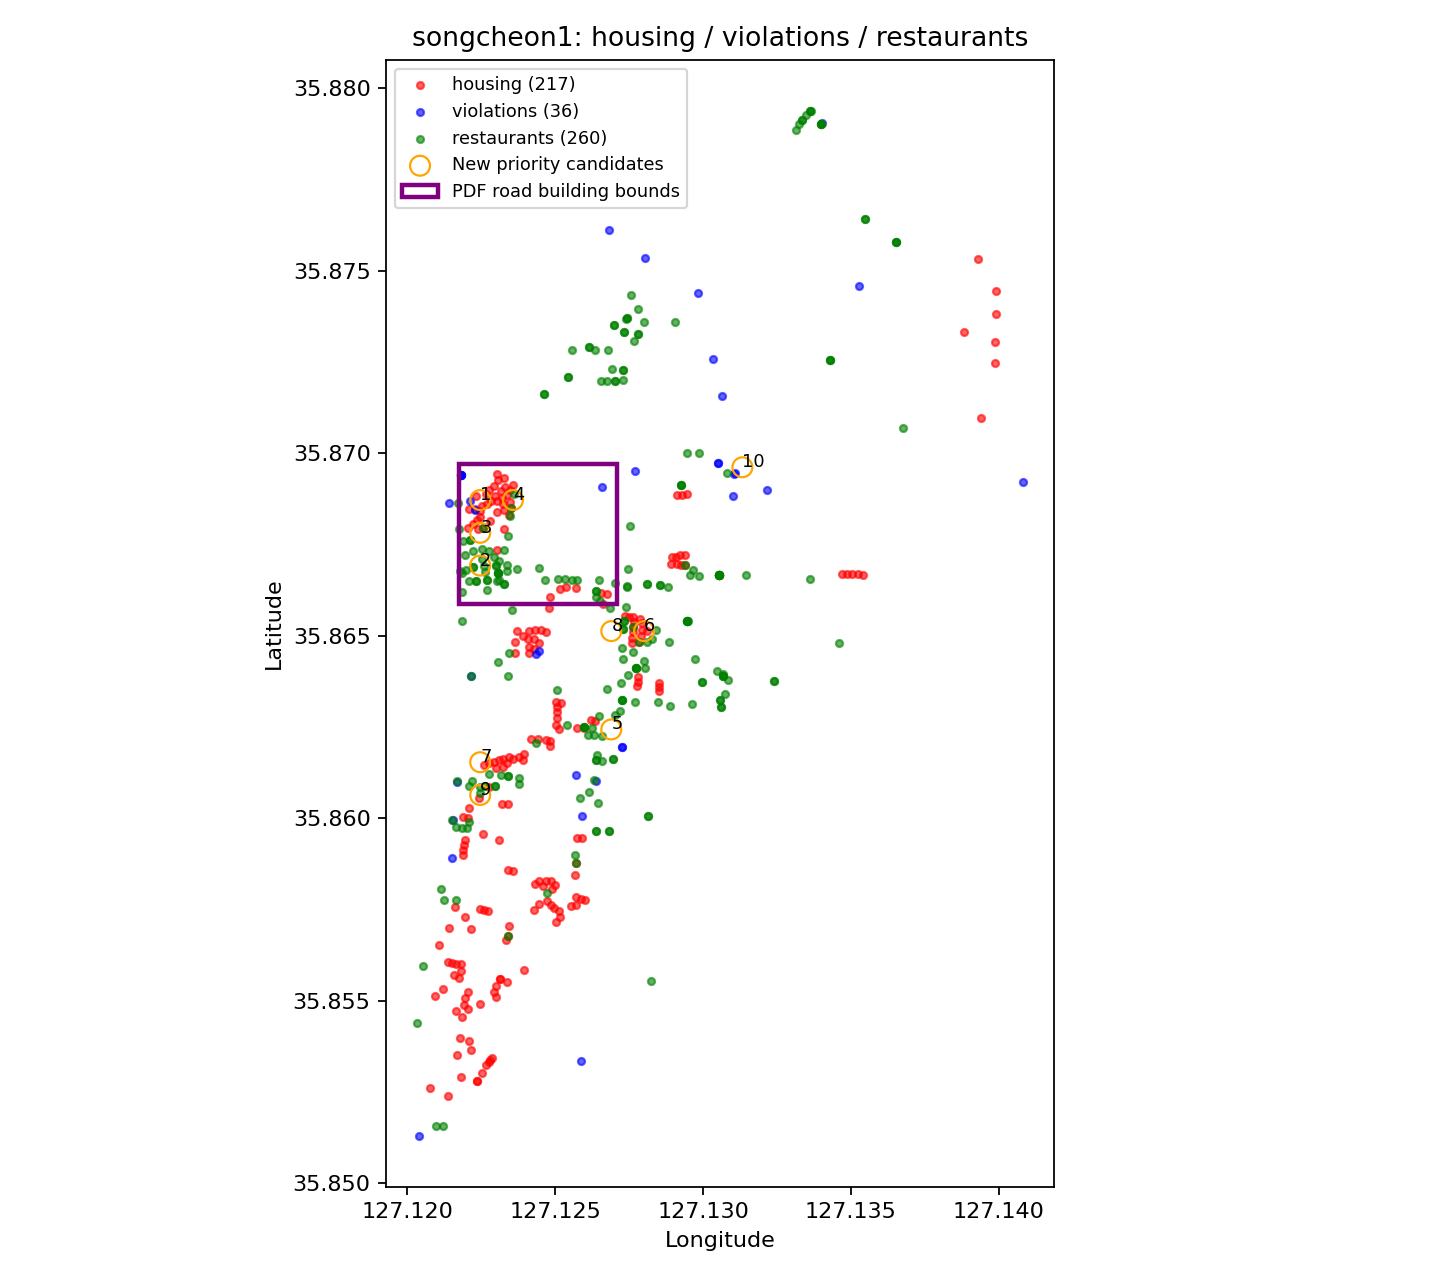

,rank,행정동,Longitude,Latitude,housing_within_100m,housing_normalized,violations_within_100m,violations_normalized,restaurants_within_100m,restaurants_normalized,score,nearest_building_address,distance_to_nearest_building_m
0,1,송천1동,127.122464,35.868721,33,1.000000,7,1.000000,3,0.081081,0.693694,전북특별자치도 전주시 덕진구 붓내5길 9,16.674955
1,2,송천1동,127.122464,35.866924,1,0.030303,0,0.000000,37,1.000000,0.343434,전북특별자치도 전주시 덕진구 붓내4길 8-7,69.569385
2,3,송천1동,127.122464,35.867822,15,0.454545,1,0.142857,13,0.351351,0.316251,전북특별자치도 전주시 덕진구 붓내4길 9,13.897298
3,4,송천1동,127.123572,35.868721,25,0.757576,0,0.000000,3,0.081081,0.279552,전북특별자치도 전주시 덕진구 붓내3길 17-21,9.375354
4,5,송천1동,127.126897,35.862433,3,0.090909,2,0.285714,16,0.432432,0.269685,전북특별자치도 전주시 덕진구 솔내9길 2-2,56.429548
5,6,송천1동,127.128005,35.865128,14,0.424242,0,0.000000,14,0.378378,0.267540,전북특별자치도 전주시 덕진구 천마산로 59-10,8.484489
6,7,송천1동,127.122464,35.861534,11,0.333333,1,0.142857,12,0.324324,0.266838,전북특별자치도 전주시 덕진구 솔내8길 23-25,14.844428
7,8,송천1동,127.126897,35.865128,14,0.424242,0,0.000000,12,0.324324,0.249522,전북특별자치도 전주시 덕진구 솔내로 172,63.438689
8,9,송천1동,127.122464,35.860636,10,0.303030,1,0.142857,11,0.297297,0.247728,전북특별자치도 전주시 덕진구 솔내8길 10-5,10.549177
9,10,송천1동,127.131330,35.869619,0,0.000000,5,0.714286,1,0.027027,0.247104,전북특별자치도 전주시 덕진구 동부대로 1073-14,188.081471


In [15]:
sites = [select_sites('송천1동')]
if ANALYZE_AUTO_SELECTED:
    summary_path = result_path('run_summary.json')
    if not summary_path.exists():
        raise FileNotFoundError('05_clustering.ipynb를 먼저 실행하거나 ANALYZE_AUTO_SELECTED=False로 설정하세요.')
    auto_dong = json.loads(summary_path.read_text(encoding='utf-8'))['top_dong']
    if auto_dong != '송천1동':
        sites.append(select_sites(auto_dong))
result_path('site_results.json').write_text(json.dumps({'commercial_coverage': commercial_metadata, 'sites': sites}, ensure_ascii=False, indent=2), encoding='utf-8')
display(Image(filename=str(result_path('site_analysis_songcheon1.png'))))
display(pd.read_csv(result_path('site_candidates_songcheon1.csv')).head(10))
display(HTML(result_path('site_analysis_songcheon1.html').read_text(encoding='utf-8')))